In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.metrics import(
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
model_df=pd.read_csv('hourlyLoadData_NE_weather_with_holiday.csv')

In [8]:
print(model_df.head(40))

          datetime  North-Eastern Region Hourly Demand  temp_ne  humidity_ne  \
0    1/1/2019 0:00                             1665.72     11.4           91   
1    1/1/2019 1:00                             1556.24     10.4           92   
2    1/1/2019 2:00                             1485.44      9.6           93   
3    1/1/2019 3:00                             1454.96      9.1           91   
4    1/1/2019 4:00                             1463.14      8.9           88   
5    1/1/2019 5:00                             1496.27      9.8           89   
6    1/1/2019 6:00                             1571.10     10.6           83   
7    1/1/2019 7:00                             1754.27     13.2           75   
8    1/1/2019 8:00                             1768.27     16.0           72   
9    1/1/2019 9:00                             1702.59     18.5           66   
10  1/1/2019 10:00                             1620.80     20.1           61   
11  1/1/2019 11:00                      

In [10]:
model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46728 entries, 0 to 46727
Data columns (total 6 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   datetime                            46728 non-null  object 
 1   North-Eastern Region Hourly Demand  46728 non-null  float64
 2   temp_ne                             46728 non-null  float64
 3   humidity_ne                         46728 non-null  int64  
 4   feels_like_ne                       46728 non-null  float64
 5   is_holiday                          46728 non-null  int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 2.1+ MB


In [11]:
model_df.describe()

,North-Eastern Region Hourly Demand,temp_ne,humidity_ne,feels_like_ne,is_holiday
count,46728.00000,46728.000000,46728.000000,46728.000000,46728.000000
mean,2007.36047,23.520611,79.603642,26.709123,0.045198
std,436.58010,5.206864,15.549451,7.344566,0.207740
min,567.00000,7.900000,16.000000,6.400000,0.000000
25%,1689.17750,20.000000,70.000000,21.000000,0.000000
50%,1968.65000,24.500000,84.000000,27.800000,0.000000
75%,2290.20250,27.200000,92.000000,32.600000,0.000000
max,3586.43000,38.800000,100.000000,44.800000,1.000000


<Axes: >

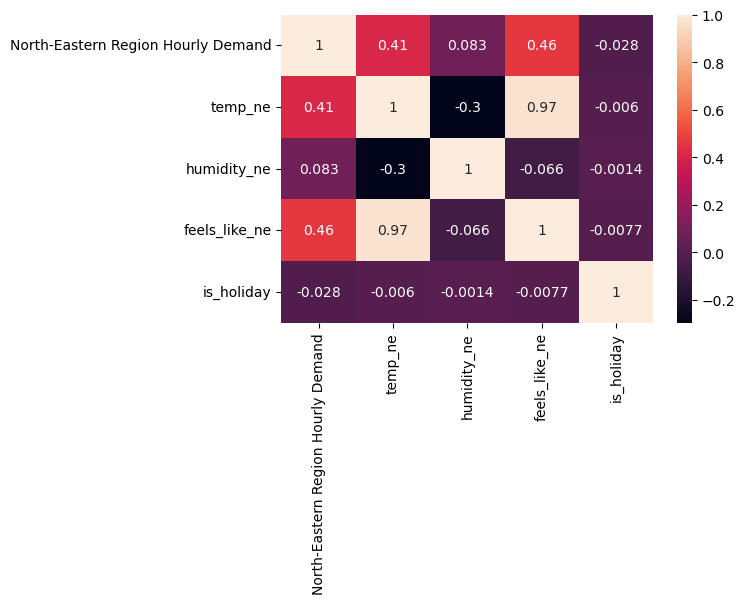

In [12]:
plt.figure(figsize=(6,4))
sns.heatmap(model_df.corr(numeric_only=True),annot=True)

In [13]:
print(model_df.dtypes)
print(model_df['datetime'].head(5))

datetime                               object
North-Eastern Region Hourly Demand    float64
temp_ne                               float64
humidity_ne                             int64
feels_like_ne                         float64
is_holiday                              int64
dtype: object
0    1/1/2019 0:00
1    1/1/2019 1:00
2    1/1/2019 2:00
3    1/1/2019 3:00
4    1/1/2019 4:00
Name: datetime, dtype: object


In [14]:
model_df['datetime']=pd.to_datetime(model_df['datetime'])
print(model_df['datetime'].dtype)
print(model_df['datetime'].head(3))

datetime64[ns]
0   2019-01-01 00:00:00
1   2019-01-01 01:00:00
2   2019-01-01 02:00:00
Name: datetime, dtype: datetime64[ns]


In [26]:
model_df['hour']=model_df['datetime'].dt.hour         
model_df['day_of_week']=model_df['datetime'].dt.dayofweek    
model_df['day_of_month']=model_df['datetime'].dt.day          
model_df['month']=model_df['datetime'].dt.month        
model_df['quarter']=model_df['datetime'].dt.quarter      
model_df['year']=model_df['datetime'].dt.year         
model_df['is_weekend']=(model_df['datetime'].dt.dayofweek >= 5).astype(int)  
print(model_df[['datetime','hour','day_of_week','month','year','is_weekend']].head(200))

               datetime  hour  day_of_week  month  year  is_weekend
0   2019-01-01 00:00:00     0            1      1  2019           0
1   2019-01-01 01:00:00     1            1      1  2019           0
2   2019-01-01 02:00:00     2            1      1  2019           0
3   2019-01-01 03:00:00     3            1      1  2019           0
4   2019-01-01 04:00:00     4            1      1  2019           0
..                  ...   ...          ...    ...   ...         ...
195 2019-01-09 03:00:00     3            2      1  2019           0
196 2019-01-09 04:00:00     4            2      1  2019           0
197 2019-01-09 05:00:00     5            2      1  2019           0
198 2019-01-09 06:00:00     6            2      1  2019           0
199 2019-01-09 07:00:00     7            2      1  2019           0

[200 rows x 6 columns]


In [27]:
model_df['hour_sin']=np.sin(2*np.pi*model_df['hour']/24)
model_df['hour_cos']=np.cos(2*np.pi*model_df['hour']/24)

model_df['dow_sin']=np.sin(2*np.pi*model_df['day_of_week']/7)
model_df['dow_cos']=np.cos(2*np.pi*model_df['day_of_week']/7)

model_df['month_sin']=np.sin(2*np.pi*model_df['month']/12)
model_df['month_cos']=np.cos(2*np.pi*model_df['month']/12)

print(model_df[['hour','hour_sin','hour_cos','day_of_week','dow_sin','dow_cos']].head(5))

   hour  hour_sin  hour_cos  day_of_week   dow_sin  dow_cos
0     0  0.000000  1.000000            1  0.781831  0.62349
1     1  0.258819  0.965926            1  0.781831  0.62349
2     2  0.500000  0.866025            1  0.781831  0.62349
3     3  0.707107  0.707107            1  0.781831  0.62349
4     4  0.866025  0.500000            1  0.781831  0.62349


In [28]:
TARGET='North-Eastern Region Hourly Demand'
model_df['lag_1h']=model_df[TARGET].shift(1)    
model_df['lag_24h']=model_df[TARGET].shift(24)
model_df['lag_48h']=model_df[TARGET].shift(48)
model_df['lag_168h']=model_df[TARGET].shift(168)
model_df['lag_336h']=model_df[TARGET].shift(336)
model_df['rolling_mean_24h']=model_df[TARGET].shift(1).rolling(24).mean()
model_df['rolling_mean_168h']=model_df[TARGET].shift(1).rolling(168).mean()
model_df['rolling_std_24h']=model_df[TARGET].shift(1).rolling(24).std()
model_df['rolling_max_24h']=model_df[TARGET].shift(1).rolling(24).max()
model_df['rolling_min_24h']=model_df[TARGET].shift(1).rolling(24).min()

model_df.head(5)

,datetime,North-Eastern Region Hourly Demand,temp_ne,humidity_ne,feels_like_ne,is_holiday,hour,day_of_week,day_of_month,month,...,lag_1h,lag_24h,lag_48h,lag_168h,lag_336h,rolling_mean_24h,rolling_mean_168h,rolling_std_24h,rolling_max_24h,rolling_min_24h
0,2019-01-01 00:00:00,1665.72,11.4,91,10.7,1,0,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-01-01 01:00:00,1556.24,10.4,92,9.6,1,1,1,1,1,...,1665.72,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-01-01 02:00:00,1485.44,9.6,93,8.5,1,2,1,1,1,...,1556.24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2019-01-01 03:00:00,1454.96,9.1,91,7.7,1,3,1,1,1,...,1485.44,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2019-01-01 04:00:00,1463.14,8.9,88,7.5,1,4,1,1,1,...,1454.96,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
print(model_df.shape)
model_df.dropna(inplace=True)
model_df.reset_index(drop=True, inplace=True)
print(model_df.shape)

(46728, 29)
(46392, 29)


In [30]:
feature_cols=[col for col in model_df.columns
                if col not in ['datetime', TARGET]]

print(f"Total features:{len(feature_cols)}")
print("\nFeatures:")
for i,col in enumerate(feature_cols, 1):
    print(f"{i:2d}.{col}")

Total features:27

Features:
 1.temp_ne
 2.humidity_ne
 3.feels_like_ne
 4.is_holiday
 5.hour
 6.day_of_week
 7.day_of_month
 8.month
 9.quarter
10.year
11.is_weekend
12.hour_sin
13.hour_cos
14.dow_sin
15.dow_cos
16.month_sin
17.month_cos
18.lag_1h
19.lag_24h
20.lag_48h
21.lag_168h
22.lag_336h
23.rolling_mean_24h
24.rolling_mean_168h
25.rolling_std_24h
26.rolling_max_24h
27.rolling_min_24h


In [31]:
print(model_df.head())

             datetime  North-Eastern Region Hourly Demand  temp_ne  \
0 2019-01-15 00:00:00                             1502.11     14.0   
1 2019-01-15 01:00:00                             1404.18     13.7   
2 2019-01-15 02:00:00                             1366.26     13.2   
3 2019-01-15 03:00:00                             1353.51     13.0   
4 2019-01-15 04:00:00                             1363.48     12.8   

   humidity_ne  feels_like_ne  is_holiday  hour  day_of_week  day_of_month  \
0           81           13.1           1     0            1            15   
1           79           12.8           1     1            1            15   
2           78           12.2           1     2            1            15   
3           78           11.6           1     3            1            15   
4           77           11.4           1     4            1            15   

   month  ...   lag_1h  lag_24h  lag_48h  lag_168h  lag_336h  \
0      1  ...  1666.11  1425.06  1471.21   148

In [15]:
model_df.isnull().sum()

datetime                              0
North-Eastern Region Hourly Demand    0
temp_ne                               0
humidity_ne                           0
feels_like_ne                         0
is_holiday                            0
hour                                  0
day_of_week                           0
day_of_month                          0
month                                 0
quarter                               0
year                                  0
is_weekend                            0
hour_sin                              0
hour_cos                              0
dow_sin                               0
dow_cos                               0
month_sin                             0
month_cos                             0
lag_1h                                0
lag_24h                               0
lag_48h                               0
lag_168h                              0
lag_336h                              0
rolling_mean_24h                      0


In [32]:
EXCLUDE=['datetime','North-Eastern Region Hourly Demand']
FEATURE_COLS=[col for col in model_df.columns if col not in EXCLUDE]
TARGET='North-Eastern Region Hourly Demand'

In [33]:
SPLIT_DATE='2023-01-01'
train=model_df[model_df['datetime']<SPLIT_DATE].copy()
test=model_df[model_df['datetime']>=SPLIT_DATE].copy()
X_train=train[FEATURE_COLS]
y_train=train[TARGET]
X_test=test[FEATURE_COLS]
y_test=test[TARGET]
print(f"X_train shape:{X_train.shape}")
print(f"X_test shape:{X_test.shape}")

X_train shape:(34728, 27)
X_test shape:(11664, 27)


In [36]:
!pip install optuna

In [38]:
!pip install lightgbm
import optuna
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
import lightgbm as lgb
import numpy as np

def objective(trial):
    params={
        'n_estimators':trial.suggest_int('n_estimators',300,2000,step=100),
        'learning_rate':trial.suggest_float('learning_rate',0.005,0.2,log=True),
        'max_depth':trial.suggest_int('max_depth',4,12),
        'num_leaves':trial.suggest_int('num_leaves',15,255),
        'min_child_samples':trial.suggest_int('min_child_samples',5,100),
        'subsample':trial.suggest_float('subsample',0.5,1.0),
        'colsample_bytree':trial.suggest_float('colsample_bytree',0.5,1.0),
        'reg_alpha':trial.suggest_float('reg_alpha',1e-3,10,log=True),
        'reg_lambda':trial.suggest_float('reg_lambda',1e-3,10,log=True),
        'random_state':42,'n_jobs':-1,'verbose':-1
    }

    tscv=TimeSeriesSplit(n_splits=5)
    scores=[]
    for train_idx,val_idx in tscv.split(X_train):
        X_tr,X_val=X_train.iloc[train_idx],X_train.iloc[val_idx]
        y_tr,y_val=y_train.iloc[train_idx],y_train.iloc[val_idx]
        model=lgb.LGBMRegressor(**params)
        model.fit(X_tr,y_tr,eval_set=[(X_val,y_val)],
                  callbacks=[lgb.early_stopping(50,verbose=False)])
        scores.append(mean_absolute_error(y_val,model.predict(X_val)))
    return np.mean(scores)

study=optuna.create_study(direction='minimize')
study.optimize(objective,n_trials=50,show_progress_bar=True)

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.5 MB ? eta -:--:--
   ------------------------------------ --- 1.3/1.5 MB 4.8 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 3.7 MB/s  0:00:00


[I 2026-07-04 12:12:29,403] A new study created in memory with name: no-name-16bb077b-5154-4160-ad31-c56c3f1809ce


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-07-04 12:12:46,698] Trial 0 finished with value: 40.65446169014014 and parameters: {'n_estimators': 1100, 'learning_rate': 0.024959413916457767, 'max_depth': 8, 'num_leaves': 142, 'min_child_samples': 29, 'subsample': 0.6317539932121574, 'colsample_bytree': 0.962411068846632, 'reg_alpha': 0.019848514847707235, 'reg_lambda': 0.9913805452835415}. Best is trial 0 with value: 40.65446169014014.
[I 2026-07-04 12:13:20,232] Trial 1 finished with value: 43.341172000392724 and parameters: {'n_estimators': 1300, 'learning_rate': 0.00510389917966012, 'max_depth': 12, 'num_leaves': 38, 'min_child_samples': 93, 'subsample': 0.8522928251009841, 'colsample_bytree': 0.740836685585871, 'reg_alpha': 0.03151010808895321, 'reg_lambda': 0.05101531041602329}. Best is trial 0 with value: 40.65446169014014.
[I 2026-07-04 12:14:13,498] Trial 2 finished with value: 41.249399106014025 and parameters: {'n_estimators': 1400, 'learning_rate': 0.0075168772161476275, 'max_depth': 11, 'num_leaves': 160, 'min_

In [39]:
print("Best MAE:",study.best_value)
print("Best params:",study.best_params)

Best MAE: 39.92443037423412
Best params: {'n_estimators': 1300, 'learning_rate': 0.015000770995259167, 'max_depth': 8, 'num_leaves': 156, 'min_child_samples': 16, 'subsample': 0.7521341922682264, 'colsample_bytree': 0.8632209220826542, 'reg_alpha': 0.0019303133577583684, 'reg_lambda': 0.027782332386613005}


In [21]:
!pip install lightgbm

In [40]:
best_params=study.best_params
best_params.update({'random_state':42,'n_jobs':-1,'verbose':-1})
final_model=lgb.LGBMRegressor(**best_params)
final_model.fit(X_train, y_train,eval_set=[(X_test, y_test)],callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=True), lgb.log_evaluation(period=100)])

print(f"Best iteration:{final_model.best_iteration_}")

Training until validation scores don't improve for 50 rounds
[100]	valid_0's l2: 15984.3
[200]	valid_0's l2: 4357.48
[300]	valid_0's l2: 3504.25
[400]	valid_0's l2: 3369.78
[500]	valid_0's l2: 3324.38
[600]	valid_0's l2: 3307.07
[700]	valid_0's l2: 3295.96
Early stopping, best iteration is:
[738]	valid_0's l2: 3294.03
Best iteration:738


In [41]:
y_pred=final_model.predict(X_test)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mean_squared_error(y_test,y_pred))
mape=np.mean(np.abs((y_test-y_pred)/y_test))*100
r2=1-np.sum((y_test-y_pred)**2)/np.sum((y_test-y_pred.mean())**2)

print(f"MAE={mae:.2f} MW")
print(f"RMSE={rmse:.2f} MW")
print(f"MAPE={mape:.2f}%")
print(f"R2={r2:.4f}")

MAE=40.88 MW
RMSE=57.39 MW
MAPE=1.89%
R2=0.9831


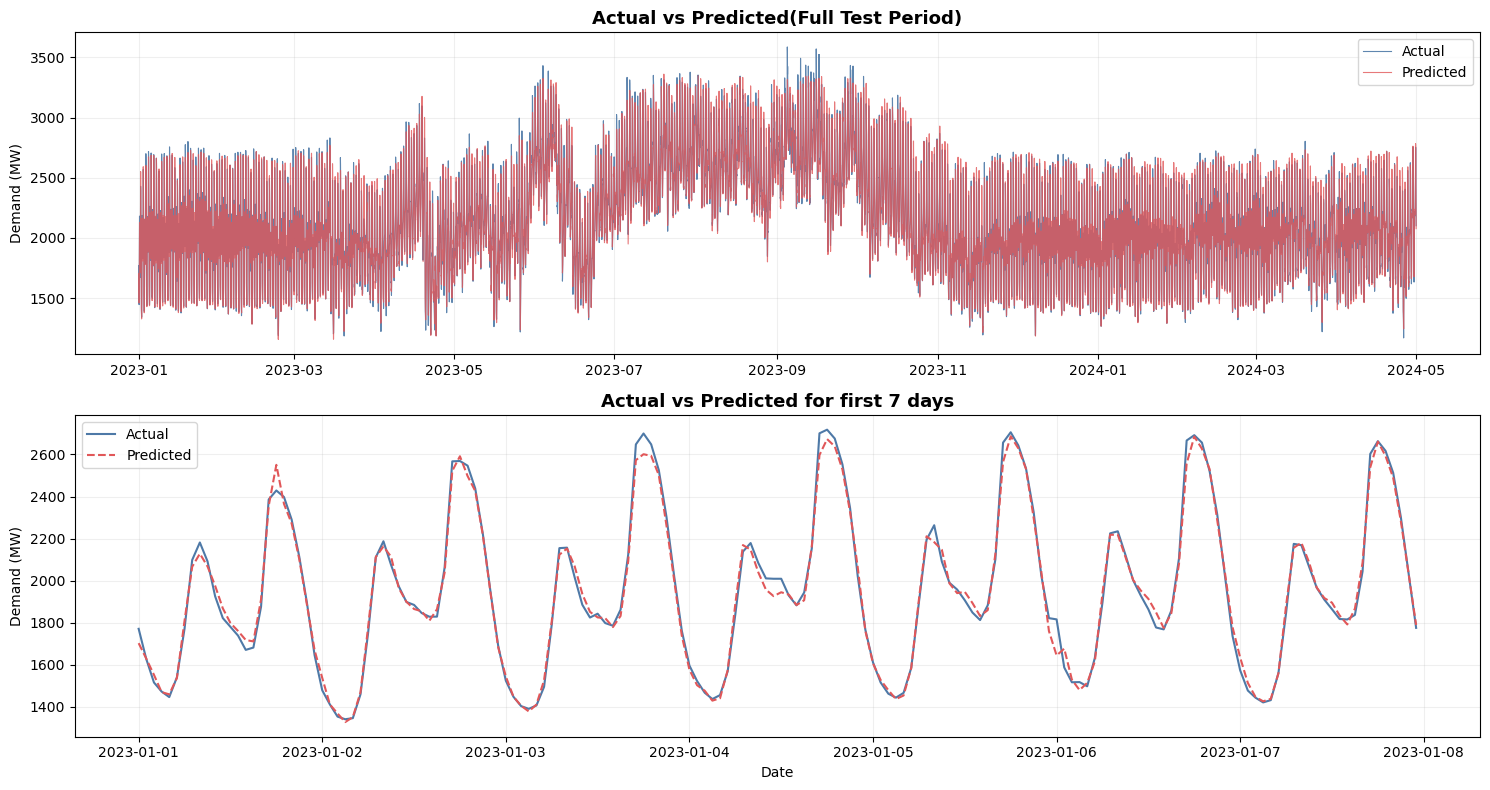

In [42]:
import matplotlib.pyplot as plt
plot_df=test.iloc[:168].copy()
plot_pred=y_pred[:168]
fig,axes=plt.subplots(2,1,figsize=(15,8))
axes[0].plot(test['datetime'],y_test.values,color='#4e79a7',linewidth=0.8,label='Actual',alpha=0.9)
axes[0].plot(test['datetime'],y_pred,color='#e15759',linewidth=0.8,label='Predicted',alpha=0.8)
axes[0].set_title('Actual vs Predicted(Full Test Period)',fontsize=13,fontweight='bold')
axes[0].set_ylabel('Demand (MW)')
axes[0].legend()
axes[0].grid(alpha=0.2)
axes[1].plot(plot_df['datetime'],plot_df[TARGET].values,color='#4e79a7',linewidth=1.5,label='Actual')
axes[1].plot(plot_df['datetime'],plot_pred,color='#e15759',linewidth=1.5,label='Predicted',linestyle='--')
axes[1].set_title('Actual vs Predicted for first 7 days',fontsize=13,fontweight='bold')
axes[1].set_ylabel('Demand (MW)')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].grid(alpha=0.2)
plt.tight_layout()
plt.savefig('lgbm_predictions_tuned.png',dpi=150)
plt.show()